In [1]:
source('utilities.R')
# read data
pw <- read.delim("data/level4ec_and_pathway/all_pathabundance_relab_unstratified.tsv",row.names = 1)
ec <- read.delim("data/level4ec_and_pathway/all_level4ec_relab_unstratified.tsv",row.names = 1)

dim(pw)
dim(ec)



Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.1 erstellt"


[1]  543 1758

[1] 2639 1758

In [ ]:
#split the data into 3 independent datasets

# pw
Austria_pw <- pw[, grepl("ERR", names(pw))]
Italy1_id <- read.table("data/level4ec_and_pathway/id_ThomasAM_Italian1.txt", header = FALSE)
Italy2_id <- read.table("data/level4ec_and_pathway/id_ThomasAM_Italian2.txt", header = FALSE)
pattern_1 <- paste(Italy1_id$V1, collapse = "|")
pattern_2 <- paste(Italy2_id$V1, collapse = "|")
Italy1_pw <- pw[, grepl(pattern_1, names(pw))]
Italy2_pw <- pw[, grepl(pattern_2, names(pw))]

Austria_pw_500k <- Austria_pw[, grepl("500K", names(Austria_pw))]
Italy1_pw_500k <- Italy1_pw[, grepl("500K", names(Italy1_pw))]
Italy2_pw_500k <- Italy2_pw[, grepl("500K", names(Italy2_pw))]

# ec
Austria_ec <- ec[, grepl("ERR", names(ec))]
pattern_1 <- paste(Italy1_id$V1, collapse = "|")
pattern_2 <- paste(Italy2_id$V1, collapse = "|")
Italy1_ec <- ec[, grepl(pattern_1, names(ec))]
Italy2_ec <- ec[, grepl(pattern_2, names(ec))]

Austria_ec_500k <- Austria_ec[, grepl("500K", names(Austria_ec))]
Italy1_ec_500k <- Italy1_ec[, grepl("500K", names(Italy1_ec))]
Italy2_ec_500k <- Italy2_ec[, grepl("500K", names(Italy2_ec))]

[1] 543 936

[1] 543 474

[1] 543 348

In [8]:
# compare Jaccard index of pathway abundance between MGS and SSMS data

# compute Jaccard index and spearman similarity for each dataset
# pw
Austria_pw_Jaccard <- compute_similarity_by_groups(Austria_pw, method = "jaccard")
Italy1_pw_Jaccard <- compute_similarity_by_groups(Italy1_pw,method ="jaccard")
Italy2_pw_Jaccard <- compute_similarity_by_groups(Italy2_pw,method = "jaccard")

Austria_pw_spearman <- compute_similarity_by_groups(Austria_pw, method = "spearman")
Italy1_pw_spearman <- compute_similarity_by_groups(Italy1_pw,method ="spearman")
Italy2_pw_spearman <- compute_similarity_by_groups(Italy2_pw,method = "spearman")

Austria_pw_rmse <- compute_similarity_by_groups(Austria_pw, method = "rmse")
Italy1_pw_rmse <- compute_similarity_by_groups(Italy1_pw,method ="rmse")
Italy2_pw_rmse <- compute_similarity_by_groups(Italy2_pw,method = "rmse")

# ec
Austria_ec_Jaccard <- compute_similarity_by_groups(Austria_ec, method = "jaccard")
Italy1_ec_Jaccard <- compute_similarity_by_groups(Italy1_ec,method ="jaccard")
Italy2_ec_Jaccard <- compute_similarity_by_groups(Italy2_ec,method = "jaccard")     
Austria_ec_spearman <- compute_similarity_by_groups(Austria_ec, method = "spearman")
Italy1_ec_spearman <- compute_similarity_by_groups(Italy1_ec,method ="spearman")
Italy2_ec_spearman <- compute_similarity_by_groups(Italy2_ec,method = "spearman")
Austria_ec_rmse <- compute_similarity_by_groups(Austria_ec, method = "rmse")
Italy1_ec_rmse <- compute_similarity_by_groups(Italy1_ec,method ="rmse")
Italy2_ec_rmse <- compute_similarity_by_groups(Italy2_ec,method = "rmse") 


Warning message:
"Paket 'scales' wurde unter R Version 4.4.1 erstellt"


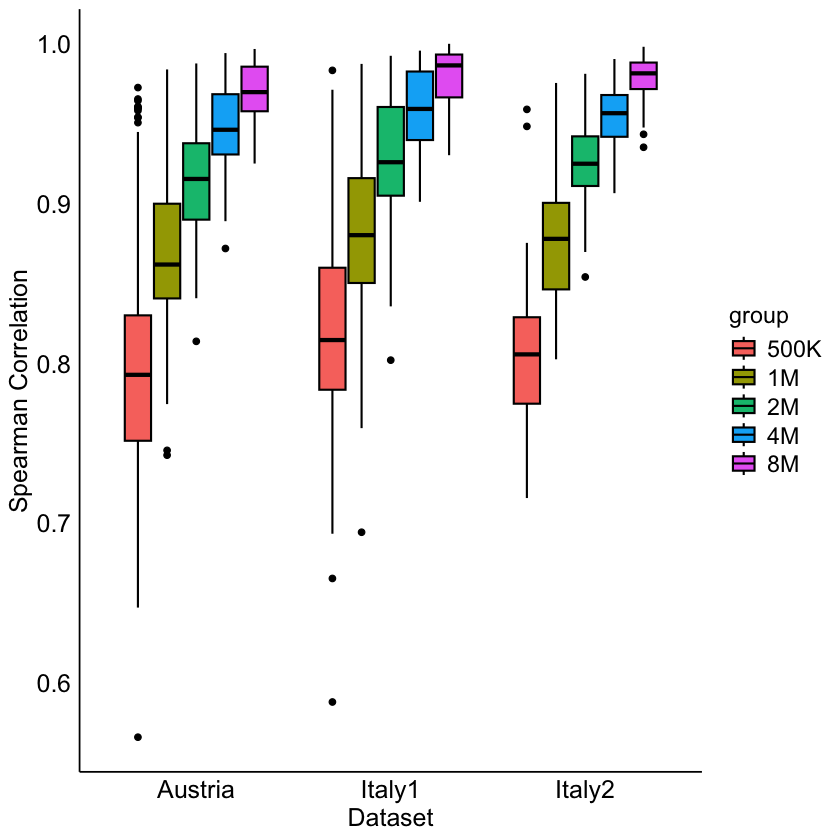

Warning message in scale_y_continuous(trans = "log10", breaks = scales::trans_breaks("log10", :
"log-10 transformation introduced infinite values."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


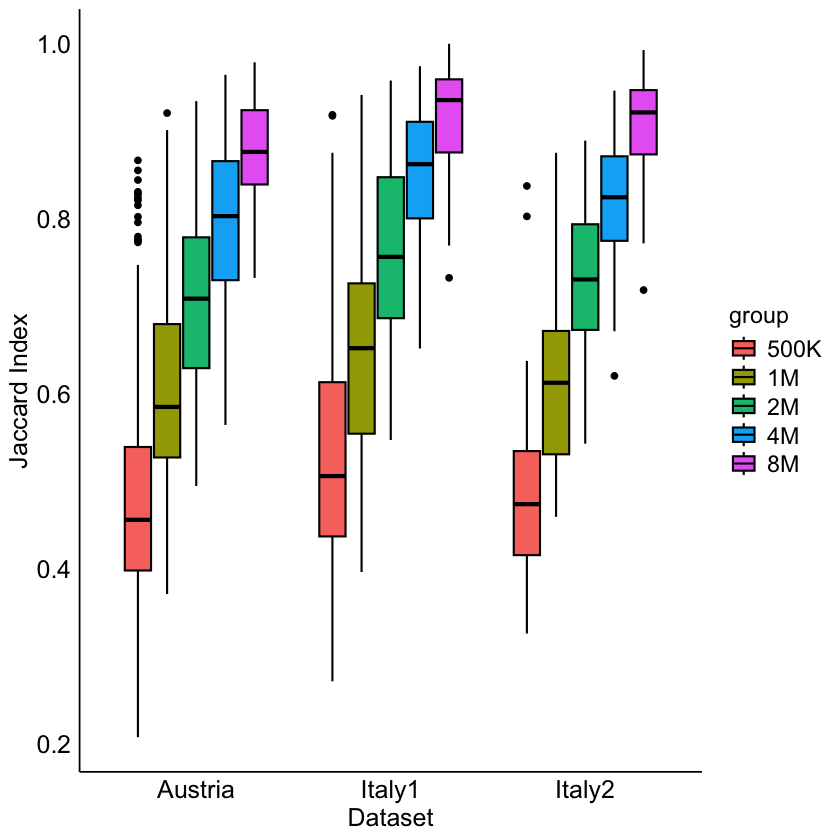

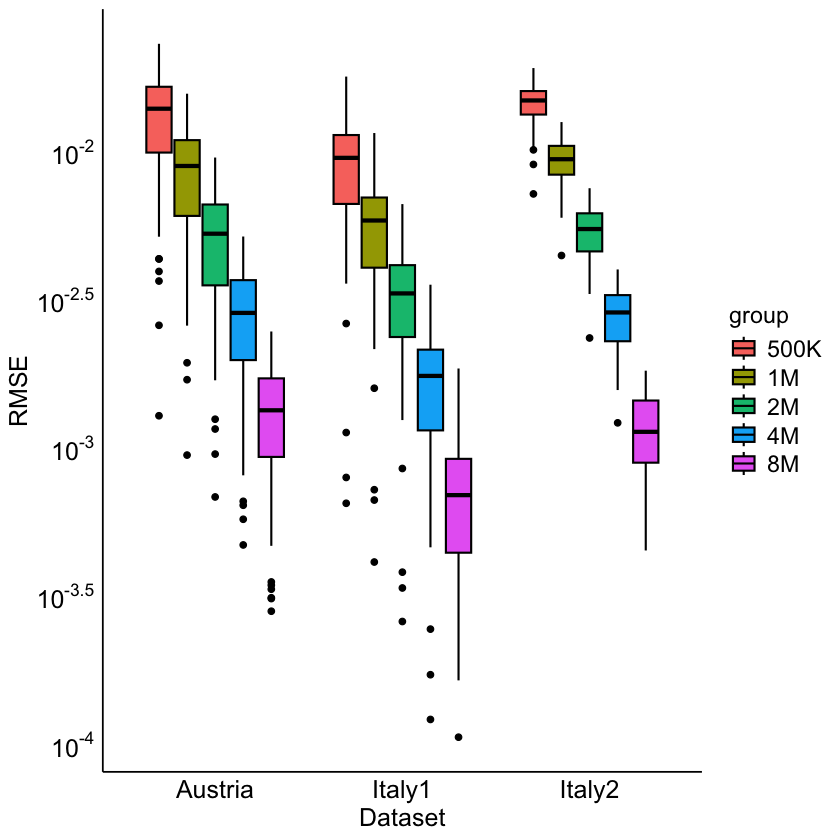

In [ ]:
# visualization - pathway 
library(ggplot2)
library(reshape2)
library(scales)

# Convert the list to a data frame for plotting


# Combine all results into a single data frame
all_results_pw <- rbind(
  result_to_df(Austria_pw_Jaccard,  "Austria", "Jaccard"),
  result_to_df(Italy1_pw_Jaccard,   "Italy1",  "Jaccard"),
  result_to_df(Italy2_pw_Jaccard,   "Italy2",  "Jaccard"),
  result_to_df(Austria_pw_spearman, "Austria", "Spearman"),
  result_to_df(Italy1_pw_spearman,  "Italy1",  "Spearman"),
  result_to_df(Italy2_pw_spearman,  "Italy2",  "Spearman"),
  result_to_df(Austria_pw_rmse,  "Austria", "rmse"),
  result_to_df(Italy1_pw_rmse, "Italy1",  "rmse"),
  result_to_df(Italy2_pw_rmse, "Italy2",  "rmse")
)
all_results_pw$group <- factor(all_results_pw$group, levels = c("500K", "1M", "2M", "4M", "8M"))

# boxplot - Spearman 
ggplot(subset(all_results_pw, method == "Spearman"), 
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +  
  labs(x = "Dataset",
       y = "Spearman Correlation") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),         
    panel.background = element_blank(),   
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14),
  )

# boxplot - Jaccard
ggplot(subset(all_results_pw, method == "Jaccard"),     
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +  
  labs(x = "Dataset",
       y = "Jaccard Index") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),         
    panel.background = element_blank(),   
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14),
  )

# boxplot - RMSE
ggplot(subset(all_results_pw, method == "rmse"),
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +
  scale_y_continuous(
    trans = "log10",
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", math_format(10^.x))
  ) +
  labs(x = "Dataset",
       y = "RMSE") +
  theme_minimal() +
  theme(    
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14)
  )



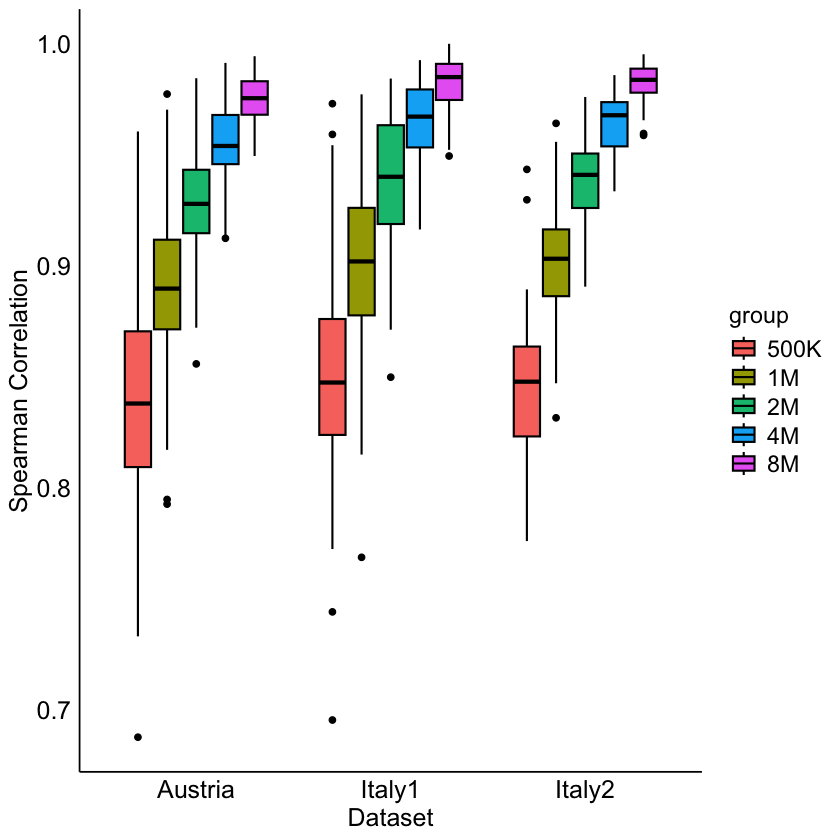

Warning message in scale_y_continuous(trans = "log10", breaks = scales::trans_breaks("log10", :
"log-10 transformation introduced infinite values."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`)."


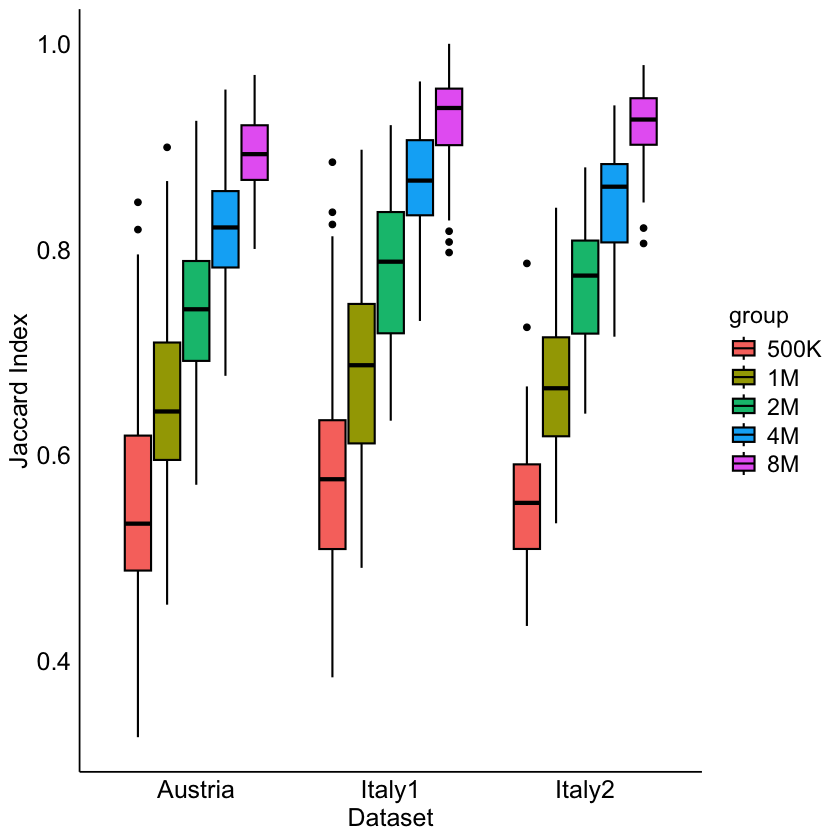

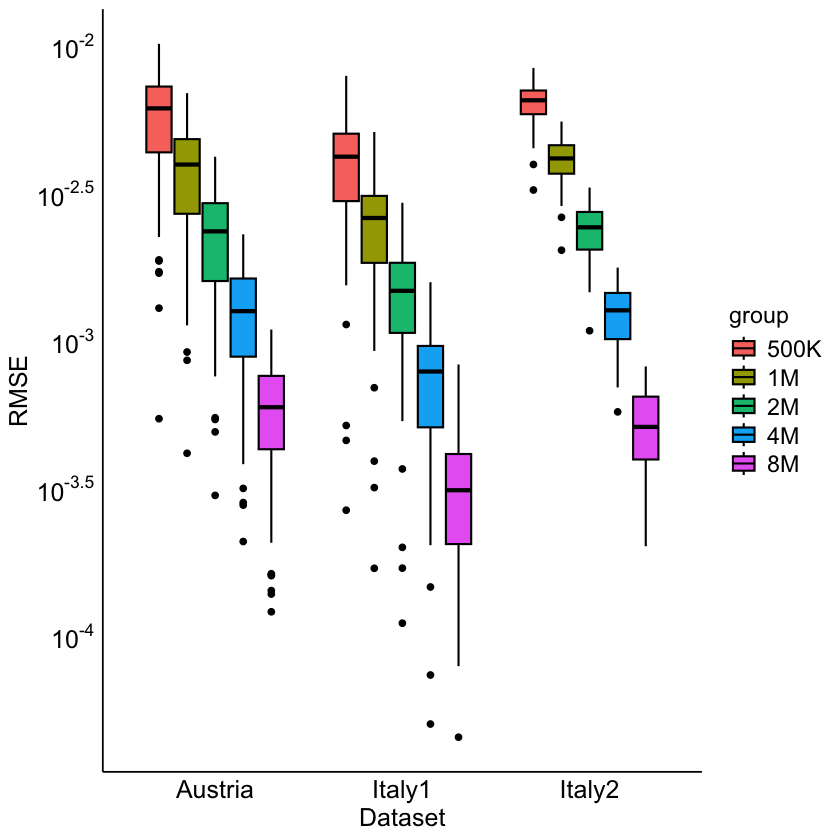

In [13]:
# visualization - EC

all_results_ec <- rbind(
  result_to_df(Austria_ec_Jaccard,  "Austria", "Jaccard"),
  result_to_df(Italy1_ec_Jaccard,   "Italy1",  "Jaccard"),
  result_to_df(Italy2_ec_Jaccard,   "Italy2",  "Jaccard"),
  result_to_df(Austria_ec_spearman, "Austria", "Spearman"),
  result_to_df(Italy1_ec_spearman,  "Italy1",  "Spearman"),
  result_to_df(Italy2_ec_spearman,  "Italy2",  "Spearman"),
  result_to_df(Austria_ec_rmse,  "Austria", "rmse"),
  result_to_df(Italy1_ec_rmse, "Italy1",  "rmse"),
  result_to_df(Italy2_ec_rmse, "Italy2",  "rmse")
)
all_results_ec$group <- factor(all_results_ec$group, levels = c("500K", "1M", "2M", "4M", "8M"))

# boxplot - Spearman 
ggplot(subset(all_results_ec, method == "Spearman"), 
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +  
  labs(x = "Dataset",
       y = "Spearman Correlation") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),         
    panel.background = element_blank(),   
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14),
  )

# boxplot - Jaccard
ggplot(subset(all_results_ec, method == "Jaccard"),     
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +  
  labs(x = "Dataset",
       y = "Jaccard Index") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),         
    panel.background = element_blank(),   
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14),
  )

# boxplot - RMSE
ggplot(subset(all_results_ec, method == "rmse"),
       aes(x = dataset, y = similarity, fill = group)) +
  geom_boxplot(color = "black", size = 0.6) +
  scale_y_continuous(
    trans = "log10",
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", math_format(10^.x))
  ) +
  labs(x = "Dataset",
       y = "RMSE") +
  theme_minimal() +
  theme(    
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(size = 15, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 14)
  )
